## This script is written for the purpose of analysising private CORS data. 
In order to analyse these data, it uses the PositioNZ network as a benchamrk that individual CORS can be tested against, have outliers removed, count the number of sites that are removed in this process and calcualte the percentage of sites from each private network that are removed. 

In [1]:
import requests
import pandas as pd
import numpy as np
import datetime
from astropy.time import Time
from LINZ.CORS_Timeseries import TimeseriesList, CoordApiTimeseries
import os 
import matplotlib.pyplot as plt
from collections import OrderedDict

The timeframe can be set to any length, as long as there is data present.

In [2]:
# Define the timeframe
start = datetime.datetime(2025, 1, 1)
end = datetime.datetime(2025, 4, 30)

#### All of the CORS sites are listed as four letter codes, these can be easily added when new sites are installed/updated down the line. 

There is a need to differentiate between the PositioNZ and private CORS sites as the PositioNZ CORS will be used to set a benchmark all of the other private CORS will be compared to.

In [3]:
code_mappings = {
    "PNcodes": "PositoNZ",
    "Vcodes": "Trimble",
    "PPcodes": "Position_Partners",
    "EScodes": "Elliot_sinclair",
    "GScodes": "Global_Survey",
    "SYcodes": "Synergy",
    "SHcodes": "Survey_Hire"
}

# Print out the PositioNZ code to ensure it has worked
print("PNcodes =", code_mappings["PNcodes"])


PNcodes = PositoNZ


The PositioNZ CORS are entered here.

In [4]:
# The PositioNZ CORS codes are printed here: 

# PositioNZ CORS
PNcodes=['AUCK','BLUF','CHTI','CORM','DNVK','DUND','GISB','GLDB','HAAS','HAMT','HAST','HIKB','HOKI','KAIK','KTIA','LEXA','LKTA','MAHO','MAVL','METH','MQZG','MTJO','NLSN','NPLY','PYGR','TAUP','TRNG',
         'VGMT','WAIM','WANG','WARK','WEST','WGTN','WHKT','WHNG','WRPA']

All of the other private CORS are entered here. These have been set up in a manner to allow new sites to be easily added.

In [5]:
# The Trimble V codes are printed here:

Vcodes=['VAK2',	'VALE',	'VCHR',	'VHAM',	'VHN2',	'VHRA',	'VLEE',	'VMAY',	'VNPE',	'VOMA',	'VOTG',	'VOTO',	'VPOA', 'VPRK',	'VPUK',	'VTEA',	'VTEK','VTEM', 'VWAN', 'VWKU', 'VWPK', 'VZQN','VOMA','VMKA',
        'VSHF','VTES','VTOK','VWK2','VWM2','VPN2']


# The Position Partners codes are printed here: 
PPcodes=['PPCW','PPNL','PPOR','PPPK','PPRS','PPSP','PPK2']
#Inactive codes=['PPMK']


# The Elliot Sinclair codes are printed here: 
EScodes=['ESBR','ESGM','ESKV','ESNL','ESPM','ESQT','ESRN','ESTR']
#Inactive codes=['ESCM']

# The Global Survey codes are printed here: 
GScodes=['GSAA','GSAB','GSAM','GSAY','GSBA','GSBD','GSCC','GSCT','GSDA','GSDR','GSGR','GSHT','GSHU','GSHW','GSIN','GSKA','GSKK','GSLI','GSLW', 'GSLX','GSMG','GSOM','GSOK','GSPE','GSPL','GSPM','GSPN',
         'GSPO','GSPR','GSPU','GSQT','GSRA','GSRL','GSRO','GSSB','GSTA','GSTH','GSTK','GSTU','GSTW','GSUH','GSUT','GSWI','GSWR','GSWU','GSNP','GSHO','GSGL','GSBN','GSBR','GSMA','GSMD','GSMO','GSPK',
         'GSWA','GSMH','GSTI','GSWH']

# The Synergy codes are printed here: 
SYcodes=['SYAS','SYCC','SYCM','SYDF','SYHA','SYHW','SYM2','SYMV','SYNL','SYQN','SYT2','SYTA','SYTS','SYWM','SYET','SYHA','SYBM','SYRD','SYLN','SYWK','SYPP']

# Survey Hire codes are printed here: 
SHcodes=['SHAR','SHMD','SHPA','SHML','SHSA']

The PositioNZ CORS data and private CORS data are downloaded with different solution type, therefore, there are two required. PositioNZ CORS use solutiontype='d20f_52_code_A', while private CORS use solutiontype='d20f_52_code_B'. 

In [6]:
# Calculate crd_epoch
crd_epoch = end + (start - end) / 2
astropy_time_object = Time(crd_epoch, format='datetime')
crd_epoch_decimal_year = astropy_time_object.decimalyear

# Initialise a dictionary to store DataFrames

daily_avg_dfs = {}

# Loop through PNcodes
for code in PNcodes:
    try:
        print(f"Processing station: {code}")
        ts = CoordApiTimeseries(code, solutiontype='d20f_52_code_A', after=start, before=end)
        dates, xyz = ts.withoutOutliers().getObs(enu=False)

        df_obs = pd.DataFrame(xyz, columns=['x', 'y', 'z'], index=dates)
        daily_avg = df_obs.resample('D').mean()
        daily_avg['date'] = daily_avg.index.strftime('%Y-%m-%d')
        daily_avg['station'] = code

        daily_avg_dfs[code] = daily_avg

    except Exception as e:
        print(f"Failed to process station {code} with error: {e}")

# Combine all station DataFrames into one
PN_data = pd.concat(daily_avg_dfs.values(), axis=0)

# Sort alphabetically by station and date
PN_data.sort_values(by=["station", "date"], inplace=True)

# Print confirmation
print("Download complete ✅")
print("PN_data DataFrame created with shape:", PN_data.shape)
print("Columns:", PN_data.columns.tolist())



Processing station: AUCK
Processing station: BLUF
Processing station: CHTI
Processing station: CORM
Processing station: DNVK
Processing station: DUND
Processing station: GISB
Processing station: GLDB
Processing station: HAAS
Processing station: HAMT
Processing station: HAST
Processing station: HIKB
Processing station: HOKI
Processing station: KAIK
Processing station: KTIA
Processing station: LEXA
Processing station: LKTA
Processing station: MAHO
Processing station: MAVL
Processing station: METH
Processing station: MQZG
Processing station: MTJO
Processing station: NLSN
Processing station: NPLY
Processing station: PYGR
Processing station: TAUP
Processing station: TRNG
Processing station: VGMT
Processing station: WAIM
Processing station: WANG
Processing station: WARK
Processing station: WEST
Processing station: WGTN
Processing station: WHKT
Processing station: WHNG
Processing station: WRPA
Download complete ✅
PN_data DataFrame created with shape: (3672, 5)
Columns: ['x', 'y', 'z', 'date',

In [7]:
# Initialize tracking set
stations_with_no_data = set()

# Dictionary to store group DataFrames
group_dataframes = {}

# Loop through all groups except PNcodes
for group_label, group_name in code_mappings.items():
    if group_label == "PNcodes":
        continue  # Skip PNcodes (already processed)

    print(f"\nProcessing group: {group_label} ({group_name})")

    # Get the actual list of station codes from the variable name
    station_list = globals().get(group_label)
    if not station_list:
        print(f"⚠️ No station list found for {group_label}")
        continue

    daily_avg_dfs = {}

    for code in station_list:
        try:
            print(f"  Processing station: {code}")
            ts = CoordApiTimeseries(code, solutiontype='d20f_52_code_B', after=start, before=end)
            dates, xyz = ts.withoutOutliers().getObs(enu=False)

            df_obs = pd.DataFrame(xyz, columns=['x', 'y', 'z'], index=dates)
            daily_avg = df_obs.resample('D').mean()
            daily_avg['date'] = daily_avg.index.strftime('%Y-%m-%d')
            daily_avg['station'] = code

            daily_avg_dfs[code] = daily_avg

        except Exception as e:
            print(f"    Failed to process station {code} with error: {e}")
            stations_with_no_data.add(code)

    if daily_avg_dfs:
        sorted_codes = sorted(daily_avg_dfs.keys())
        group_df = pd.concat([daily_avg_dfs[code] for code in sorted_codes], axis=0)
        group_df.sort_values(by=["station", "date"], inplace=True)

        df_name = group_label.replace("codes", "_data")
        group_dataframes[df_name] = group_df

        print("Download complete ✅")
        print(f"{df_name} DataFrame created with shape: {group_df.shape}")
        print(f"Columns: {group_df.columns.tolist()}")

    else:
        print(f"⚠️ No data collected for group: {group_label}")



Processing group: Vcodes (Trimble)
  Processing station: VAK2
  Processing station: VALE
  Processing station: VCHR
  Processing station: VHAM
  Processing station: VHN2
  Processing station: VHRA
  Processing station: VLEE
  Processing station: VMAY
  Processing station: VNPE
  Processing station: VOMA
  Processing station: VOTG
  Processing station: VOTO
  Processing station: VPOA
  Processing station: VPRK
  Processing station: VPUK
  Processing station: VTEA
  Processing station: VTEK
  Processing station: VTEM
  Processing station: VWAN
  Processing station: VWKU
  Processing station: VWPK
  Processing station: VZQN
  Processing station: VOMA
  Processing station: VMKA
  Processing station: VSHF
  Processing station: VTES
  Processing station: VTOK
  Processing station: VWK2
  Processing station: VWM2
  Processing station: VPN2
Download complete ✅
V_data DataFrame created with shape: (2809, 5)
Columns: ['x', 'y', 'z', 'date', 'station']

Processing group: PPcodes (Position_Partne

In [8]:
# Move PN_data to the top of the dictionary
group_dataframes = OrderedDict([("PN_data", PN_data)] + [(k, v) for k, v in group_dataframes.items() if k != "PN_data"])

#### Check that all of the dataframes have printed correctly 

In [9]:
print("Current group DataFrames:")
for df_name in group_dataframes.keys():
    print(f" - {df_name}")

Current group DataFrames:
 - PN_data
 - V_data
 - PP_data
 - ES_data
 - GS_data
 - SY_data
 - SH_data


#### Define the dataframes that the converted coordinates will fill

In [10]:
# Define the columns you expect after conversion
converted_columns = ['x', 'y', 'z', 'date', 'station', 'nztm2000_lon', 'nztm2000_lat', 'nzvd2016_elev']

# Dictionary to hold the empty DataFrames
empty_converted_dfs = {}

# Loop through each group name in your original group_dataframes
for name in group_dataframes.keys():
    # Create an empty DataFrame with the expected columns
    empty_df = pd.DataFrame(columns=converted_columns)
    
    # Store it with a "_converted" suffix
    empty_converted_dfs[f"{name}_converted"] = empty_df

# Optional: Check one of them
print(empty_converted_dfs["PN_data_converted"].head())


Empty DataFrame
Columns: [x, y, z, date, station, nztm2000_lon, nztm2000_lat, nzvd2016_elev]
Index: []


Convert the data in the dataframes from the ITRF coordinate system, to NZTM2000/NZVD2016

In [11]:
converted_group_dataframes = {}

def convert_coordinates(input_crds, crd_epoch_decimal_year):
    occ_api = "https://www.geodesy.linz.govt.nz/api/conversions/v1/convert-to"
    coordlist = {
        "crs": "LINZ:ITRF2020_XYZ",
        "coordinateOrder": ["geocentricX", "geocentricY", "geocentricZ"],
        "coordinateEpoch": crd_epoch_decimal_year,
        "coordinates": input_crds
    }
    params = {"crs": "LINZ:NZTM/NZVD2016"}

    response = requests.post(occ_api, params=params, json=coordlist)
    if response.status_code == 200:
        converted = response.json()
        return converted['coordinateList']['coordinates']
    else:
        print(f"❌ API conversion failed with status {response.status_code}")
        print(f"🔍 Error details: {response.text}")
        return []



In [12]:
for name, original_df in group_dataframes.items():
    print(f"\n🔄 Processing DataFrame: {name}")

    # Always start with a fresh copy
    df = original_df.copy(deep=True)

    # Identify and print NaN values
    nan_values = df[df.isna().any(axis=1)]
    if not nan_values.empty:
        print(f" - Found {len(nan_values)} NaN rows")

    # Identify and print Infinity values
    inf_values = df[(df == np.inf) | (df == -np.inf)].dropna(how='all')
    if not inf_values.empty:
        print(f" - Found {len(inf_values)} Inf rows")

    # Filter out invalid rows
    df_filtered = df.dropna(subset=['x', 'y', 'z']).copy()
    df_filtered = df_filtered[
        (df_filtered['x'] != np.inf) & (df_filtered['x'] != -np.inf) &
        (df_filtered['y'] != np.inf) & (df_filtered['y'] != -np.inf) &
        (df_filtered['z'] != np.inf) & (df_filtered['z'] != -np.inf)
    ].copy()

    if df_filtered.empty:
        print(f"⚠️ Skipping {name} — no valid coordinates after filtering.")
        continue

    # Prepare coordinates
    input_crds = df_filtered[['x', 'y', 'z']].values.tolist()

    # Convert coordinates
    converted_coords = convert_coordinates(input_crds, crd_epoch_decimal_year)

    # Add converted coordinates to DataFrame
    if converted_coords:
        df_filtered[['nztm2000_lon', 'nztm2000_lat', 'nzvd2016_elev']] = pd.DataFrame(
            converted_coords, index=df_filtered.index
        )

        # Store in the pre-initialised DataFrame
        converted_name = f"{name}_converted"
        if converted_name in empty_converted_dfs:
            empty_converted_dfs[converted_name] = df_filtered.copy(deep=True)
            print(f"✅ {converted_name} filled and updated.")
        else:
            print(f"⚠️ {converted_name} not found in empty_converted_dfs. Skipping storage.")
    else:
        print(f"❌ Conversion failed for {name}. No coordinates added.")



🔄 Processing DataFrame: PN_data
 - Found 9 NaN rows
✅ PN_data_converted filled and updated.

🔄 Processing DataFrame: V_data
 - Found 201 NaN rows
✅ V_data_converted filled and updated.

🔄 Processing DataFrame: PP_data
 - Found 40 NaN rows
✅ PP_data_converted filled and updated.

🔄 Processing DataFrame: ES_data
 - Found 2 NaN rows
✅ ES_data_converted filled and updated.

🔄 Processing DataFrame: GS_data
 - Found 87 NaN rows
✅ GS_data_converted filled and updated.

🔄 Processing DataFrame: SY_data
 - Found 21 NaN rows
✅ SY_data_converted filled and updated.

🔄 Processing DataFrame: SH_data
 - Found 42 NaN rows
✅ SH_data_converted filled and updated.


#### Make sure that the ITRF cooridinates are being converted into NZTM/NZVD2016 correctly by priting the headers of the dataframes

In [13]:
for name, df in converted_group_dataframes.items():
    print(f"\n{name} DataFrame head:")
    print(df.head())

### All of the dataframes should now be ready for analysis. 

The next set of cells will calcualte the statistics for each station in each network. The goal here is to create a benchmark in the form of the statistics of the whole PositioNZ network, where we can test the statistics of each station in each priviate network against. This will provide information on which stations are misbehaving/not as good, and which networks have more sites that are excluded from the model due to outliers. 

Start by defining the 'drift' in the x, y and z directions. 
This is shown as: 

$$ 
\sqrt{ \bar{x}_{\text{Longitude}} }
$$
$$
\sqrt{ \bar{y}_{\text{Latitude}} }
$$
$$
\sqrt{ \bar{z}_{\text{Elevation}} }
$$

In [14]:
# Function to calculate RMS position
def calculate_rms_position(df):
    return (
        np.sqrt(np.mean(df['nztm2000_lon']**2)),
        np.sqrt(np.mean(df['nztm2000_lat']**2)),
        np.sqrt(np.mean(df['nzvd2016_elev']**2))
    )

In [15]:
# Use the in-memory DataFrames directly

converted_group_dataframes = empty_converted_dfs
del empty_converted_dfs

dataframes = converted_group_dataframes

In [16]:
# Function to compute drift stats
def compute_drift_stats(df):
    rms_lon, rms_lat, rms_elev = calculate_rms_position(df)
    df['horizontal_drift'] = np.sqrt((df['nztm2000_lon'] - rms_lon)**2 + (df['nztm2000_lat'] - rms_lat)**2)
    df['3d_drift'] = np.sqrt(df['horizontal_drift']**2 + (df['nzvd2016_elev'] - rms_elev)**2)
    df['3d_drift_mm'] = df['3d_drift'] * 1000

    mean_drift = df['3d_drift_mm'].mean()
    std_drift = df['3d_drift_mm'].std()
    thresholds = [0.01, 0.02, 0.05]
    percentages = [(df['3d_drift'] <= t).mean() * 100 for t in thresholds]

    return mean_drift, std_drift, percentages

In [17]:
results = []

for name, df in converted_group_dataframes.items():
    df['date'] = pd.to_datetime(df['date'])

    for station in df['station'].unique():
        station_df = df[df['station'] == station].copy()
        mean_drift, std_drift, percentages = compute_drift_stats(station_df)
        results.append([station, mean_drift, std_drift] + percentages)


In [18]:
# Create summary table
columns = [
    'Station', 'Mean 3D Drift (mm)', 'Std 3D Drift (mm)',
    'Within 1 cm (%)', 'Within 2 cm (%)', 'Within 5 cm (%)'
]
summary_df = pd.DataFrame(results, columns=columns)

# Display the table
print(summary_df.to_string(index=False))

Station  Mean 3D Drift (mm)  Std 3D Drift (mm)  Within 1 cm (%)  Within 2 cm (%)  Within 5 cm (%)
   AUCK            5.255837           2.288821        97.058824       100.000000       100.000000
   BLUF            5.218572           2.333259        99.019608       100.000000       100.000000
   CHTI            5.998368           2.481890        94.117647       100.000000       100.000000
   CORM            5.641620           2.620853        95.098039       100.000000       100.000000
   DNVK            5.182429           2.714672        96.078431       100.000000       100.000000
   DUND            5.387913           2.383046        95.098039       100.000000       100.000000
   GISB            4.758937           2.300018        96.078431       100.000000       100.000000
   GLDB            5.723663           3.081948        90.000000       100.000000       100.000000
   HAAS            6.736872           2.740830        86.274510       100.000000       100.000000
   HAMT            5

These are the statistics for each of the CORS sites. They show the percentage of the data for each site that falls within a 3D drift of 1, 2 and 5cm. This is helpful to know as it can help outline sites that are noisy. However, with over 100 private CORS sites, this method is a little tiresome, and doesn't outline very well sites that exceed a given threshold, and therefore should be discarded from the model.  

#### The next cells will focus on comparing the statistics of each network.

In [19]:
PN_data_converted = converted_group_dataframes.get("PN_data_converted")

if PN_data_converted is None:
    print("❌ 'PN_data_converted' not found. Make sure it was created and filled correctly.")
else:
    # Proceed with your analysis
    PN_data_converted['date'] = pd.to_datetime(PN_data_converted['date'])



In [20]:

# Function to calculate RMS position
def calculate_rms_position(df):
    rms_lon = np.sqrt(np.mean(df['nztm2000_lon']**2))
    rms_lat = np.sqrt(np.mean(df['nztm2000_lat']**2))
    rms_elev = np.sqrt(np.mean(df['nzvd2016_elev']**2))
    return rms_lon, rms_lat, rms_elev

# Function to compute drift stats with IQR filtering
def compute_drift_stats(df, rms_lon, rms_lat, rms_elev):
    df['horizontal_drift'] = np.sqrt((df['nztm2000_lon'] - rms_lon)**2 + (df['nztm2000_lat'] - rms_lat)**2)
    df['3d_drift'] = np.sqrt(df['horizontal_drift']**2 + (df['nzvd2016_elev'] - rms_elev)**2)
    df['3d_drift_mm'] = df['3d_drift'] * 1000

    # Apply IQR filter
    Q1 = df['3d_drift_mm'].quantile(0.25)
    Q3 = df['3d_drift_mm'].quantile(0.75)
    IQR = Q3 - Q1
    filtered_df = df[(df['3d_drift_mm'] >= Q1 - 1.5 * IQR) & (df['3d_drift_mm'] <= Q3 + 1.5 * IQR)]

    mean_drift = filtered_df['3d_drift_mm'].mean()
    std_drift = filtered_df['3d_drift_mm'].std()

    return mean_drift, std_drift

# Calculate statistics for each station
station_stats = []
for station in PN_data_converted['station'].unique():
    station_df = PN_data_converted[PN_data_converted['station'] == station].copy()
    rms_lon, rms_lat, rms_elev = calculate_rms_position(station_df)
    mean_drift, std_drift = compute_drift_stats(station_df, rms_lon, rms_lat, rms_elev)
    station_stats.append((station, mean_drift, std_drift))

# Convert to DataFrame
station_stats_df = pd.DataFrame(station_stats, columns=['Station', 'Mean 3D Drift (mm)', 'Std 3D Drift (mm)'])

# Compute network-level stats
network_mean_drift = station_stats_df['Mean 3D Drift (mm)'].mean()
network_std_drift = station_stats_df['Mean 3D Drift (mm)'].std()

# Output
print("📍 Station-level 3D Drift Statistics:")
print(station_stats_df.to_string(index=False))

print("\n🌐 Network-level 3D Drift Statistics:")
print(f"Mean 3D Drift (mm): {network_mean_drift:.3f}")
print(f"Std 3D Drift (mm): {network_std_drift:.3f}")


📍 Station-level 3D Drift Statistics:
Station  Mean 3D Drift (mm)  Std 3D Drift (mm)
   AUCK            5.115550           2.072225
   BLUF            5.110227           2.071043
   CHTI            5.928510           2.391363
   CORM            5.460137           2.291549
   DNVK            4.874103           2.069188
   DUND            5.110866           1.978261
   GISB            4.510245           1.823153
   GLDB            5.603054           2.850583
   HAAS            6.658622           2.637514
   HAMT            5.055151           2.416943
   HAST            4.552122           1.990326
   HIKB            4.267153           2.041611
   HOKI            5.355094           2.265291
   KAIK            4.802268           1.867627
   KTIA            5.167708           2.065868
   LEXA            6.820378           3.221385
   LKTA            5.352385           2.219873
   MAHO            5.210863           2.367555
   MAVL            5.959928           2.883943
   METH            5.28

Use the statistics from all of the PositioNZ CORS to set a benchmark, that each individual private CORS site can be tested against.

Set these statisteics as the benchmark, so that individual CORS sites can be tested against this. 

In [21]:
# Store benchmark statistics
benchmark_stats = {
    "mean_drift_mm": network_mean_drift,
    "std_drift_mm": network_std_drift
}

Here is where the other CORS sites are tested agasint the PositioNZ network. The private CORS site is 'rejected' if the standard deviation of 3D drift is greater than 2 standard deviation from the benchmark. 

In [22]:
print(converted_group_dataframes.keys())


dict_keys(['PN_data_converted', 'V_data_converted', 'PP_data_converted', 'ES_data_converted', 'GS_data_converted', 'SY_data_converted', 'SH_data_converted'])


In [23]:
# Mapping of internal codes to full network names
network_mapping = {
    "V_data_converted": "Trimble",
    "PP_data_converted": "Position Partners",
    "ES_data_converted": "Elliot Sinclair",
    "GS_data_converted": "Global Survey",
    "SH_data_converted": "Survey Hire",
    "SY_data_converted": "Synergy"
}

# Analyse all other networks
results = []

for network_key, df in converted_group_dataframes.items():
    if network_key == "PN_data_converted":
        continue  # Skip the benchmark

    df['date'] = pd.to_datetime(df['date'])

    # Get the readable network name
    network_name = network_mapping.get(network_key, network_key)

    for station in df['station'].unique():
        station_df = df[df['station'] == station].copy()
        
        # Compute station-specific RMS
        rms_lon, rms_lat, rms_elev = calculate_rms_position(station_df)
        
        # Compute drift relative to its own RMS
        mean_drift, std_drift = compute_drift_stats(station_df, rms_lon, rms_lat, rms_elev)
        
        # Compare to benchmark
        deviation_from_benchmark = (mean_drift - benchmark_stats["mean_drift_mm"]) / benchmark_stats["std_drift_mm"]
        
        if deviation_from_benchmark >= 2: ### Change this to remove more or less sites using the filter
            results.append([network_name, station, mean_drift, std_drift, deviation_from_benchmark])

# Create summary table
columns = ['Network', 'Station', 'Mean 3D Drift (mm)', 'Std 3D Drift (mm)', 'Deviation from Benchmark (std)']
summary_df = pd.DataFrame(results, columns=columns)

# Display the table
print(summary_df.to_string(index=False))


          Network Station  Mean 3D Drift (mm)  Std 3D Drift (mm)  Deviation from Benchmark (std)
          Trimble    VAK2            7.208571           3.043205                        3.431620
          Trimble    VPN2            6.463653           2.860305                        2.099268
          Trimble    VTEA            7.322060           3.440828                        3.634605
          Trimble    VWAN            6.642808           2.978200                        2.419703
Position Partners    PPCW            7.419812           3.521501                        3.809444
Position Partners    PPSP            8.524205           3.175908                        5.784751
  Elliot Sinclair    ESPM            7.460738           3.805823                        3.882644
  Elliot Sinclair    ESQT            6.494393           2.753554                        2.154249
    Global Survey    GSCT            6.625537           2.716952                        2.388812
    Global Survey    GSIN     

These are all of the sites that are rejected on the basis that they have too much daily drift. Below is the statistical printout, i.e., what is the percentage of sites that are rejected. 

In [24]:
# Count total number of unique stations across all DataFrames, excluding 'PN_data_converted'
total_stations = set()
excluded_stations = set()

for network_key, df in converted_group_dataframes.items():
    if network_key == "PN_data_converted":
        continue  # Skip the benchmark

    for station in df['station'].unique():
        total_stations.add(station)

# Count how many stations were excluded based on the summary_df
for station in summary_df['Station'].unique():
    excluded_stations.add(station)

# Calculate the percentage of excluded stations
total_station_count = len(total_stations)
excluded_station_count = len(excluded_stations)
percentage_excluded = (excluded_station_count / total_station_count) * 100

# Print exclusion statistics
print(f"Total stations analysed: {total_station_count}")
print(f"Number of stations excluded: {excluded_station_count}")
print(f"Percentage of stations excluded: {percentage_excluded:.2f}%")

Total stations analysed: 126
Number of stations excluded: 20
Percentage of stations excluded: 15.87%


In [25]:
# Count total number of unique stations across all DataFrames, excluding 'PN_data_converted'
total_stations = set()
excluded_stations = set()
stations_with_no_data = set()

for network_key, df in converted_group_dataframes.items():
    if network_key == "PN_data_converted":
        continue  # Skip the benchmark

    for station in df['station'].unique():
        total_stations.add(station)
        # Check if the station has no data (i.e., all rows for that station are empty)
        if df[df['station'] == station].dropna(how='all').empty:
            stations_with_no_data.add(station)

# Count how many stations were excluded based on the summary_df
for station in summary_df['Station'].unique():
    excluded_stations.add(station)

# Calculate the percentage of excluded stations
total_station_count = len(total_stations)
excluded_station_count = len(excluded_stations)
percentage_excluded = (excluded_station_count / total_station_count) * 100

# Calculate the percentage of stations with no data
stations_with_no_data_count = len(stations_with_no_data)
percentage_no_data = (stations_with_no_data_count / total_station_count) * 100

# Print exclusion statistics
print(f"Total stations analysed: {total_station_count}")
print(f"Number of stations excluded: {excluded_station_count}")
print(f"Percentage of stations excluded: {percentage_excluded:.2f}%")
print(f"Number of stations with no data: {stations_with_no_data_count}")
print(f"Percentage of stations with no data: {percentage_no_data:.2f}%")


Total stations analysed: 126
Number of stations excluded: 20
Percentage of stations excluded: 15.87%
Number of stations with no data: 0
Percentage of stations with no data: 0.00%


#### Next, a plot will help visualise how many sites per network are excluded. This will help to understand the networks that are underperforming. 

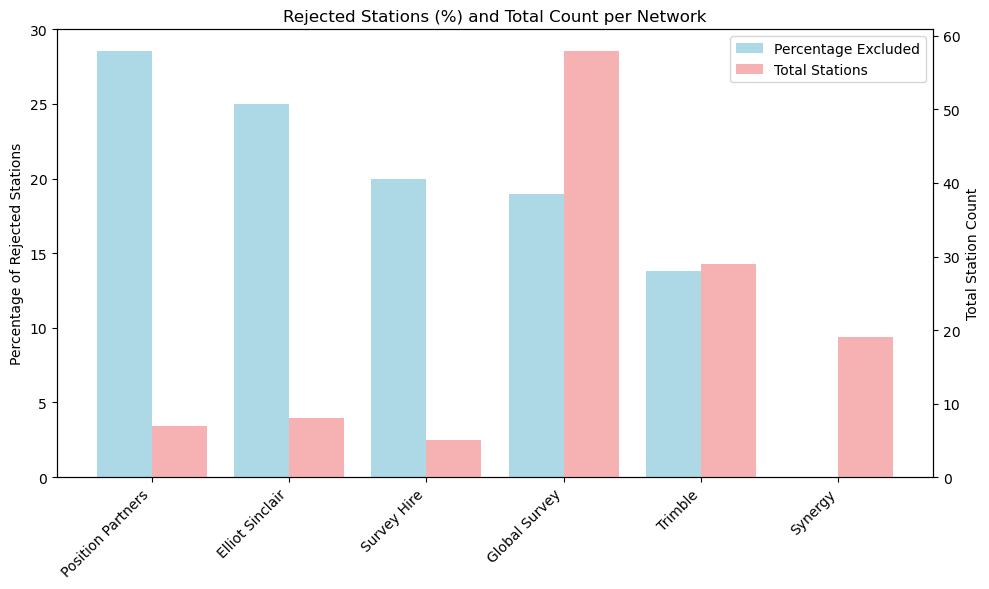

In [26]:
# Calculate the percentage of excluded stations per network and total station count
network_exclusion_percentages = {}
network_total_stations = {}

for network_key, df in converted_group_dataframes.items():
    if network_key == "PN_data_converted":
        continue  # Skip the benchmark

    network_name = network_mapping.get(network_key, network_key)
    
    total_stations = set(df['station'].unique())
    excluded_stations = set(summary_df[summary_df['Network'] == network_name]['Station'].unique())
    
    total_station_count = len(total_stations)
    excluded_station_count = len(excluded_stations)
    
    percentage_excluded = (excluded_station_count / total_station_count) * 100
    network_exclusion_percentages[network_name] = percentage_excluded
    network_total_stations[network_name] = total_station_count

# Convert to Series
percentage_excluded_series = pd.Series(network_exclusion_percentages)
total_stations_series = pd.Series(network_total_stations)

# Sort by percentage for consistent x-axis
sorted_networks = percentage_excluded_series.sort_values(ascending=False).index

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for percentage excluded
bar_width = 0.4
x = range(len(sorted_networks))
ax1.bar([i - bar_width/2 for i in x], percentage_excluded_series[sorted_networks], 
        width=bar_width, color='lightblue', label='Percentage Excluded')
ax1.set_ylabel('Percentage of Rejected Stations', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(sorted_networks, rotation=45, ha='right')

# Bar chart for total station count on the same x-axis
ax2 = ax1.twinx()
ax2.bar([i + bar_width/2 for i in x], total_stations_series[sorted_networks], 
        width=bar_width, color='lightcoral', alpha=0.6, label='Total Stations')
ax2.set_ylabel('Total Station Count', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Add legends
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

plt.title('Rejected Stations (%) and Total Count per Network')
plt.tight_layout()
plt.show()


#### This final step creates a CSV file of the average positons of each of the private cors sites for mapping purposes. 

In [34]:
# Exclude 'PN_data_converted' from the dictionary
dataframes_to_combine = {
    k: v for k, v in converted_group_dataframes.items() if k != 'PN_data_converted'
}

# Combine all remaining DataFrames
combined_df = pd.concat(dataframes_to_combine.values())

# Calculate average coordinates per station
average_coordinates = combined_df.groupby('station').agg({
    'nztm2000_lon': 'mean',
    'nztm2000_lat': 'mean',
    'nzvd2016_elev': 'mean'
}).reset_index()

# Rename columns
average_coordinates.columns = ['Station', 'NZTM2000_Longitude', 'NZTM2000_Latitude', 'NZVD2016_Elevation']

# Export to CSV
average_coordinates.to_csv('Private_CORS_coordinates.csv', index=False)

print("✅ CSV file 'Private_CORS_cordinates.csv' has been created.")


✅ CSV file 'Private_CORS_cordinates.csv' has been created.
